In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [ ]:
# sheet 1 to sheet 17 Convinience
# sheet 18 To sheet 31  Iceland
# Sheet 32 to sheet 55 Supermarkets
# Sheet 56 to Sheet 72  Tesco

In [33]:
# for i in range(1,8):
#   if i==1:

#     file_path = '/content/D1_L1_Brand_L2_PPG.xlsx'
#   else:
#     file_path = f'/content/D1_L1_Brand_L2_PPG ({i}).xlsx'
file_path='/content/D1_L1_Brand_L2_PPG.xlsx'
xls = pd.ExcelFile(file_path)


data_frames = []
for sheet_name in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name)


    data_frames.append(df)

,Sheet Number,Original Sheet Name
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
67,0,0
68,0,0
69,0,0
70,0,0


,Market,Channel,Region,Category,SubCategory,Brand,Variant,PackType,PPG,PackSize,...,EV6_Comp@Direct,EV6_Comp@Indirect,PPU_cann,PPU_Comp@Direct,PPU_Comp@Indirect,PPL_cann,PPL_Comp@Direct,PPL_Comp@Indirect,Up_Down_Index,Cat_Pr_Index


In [44]:
df_beans=data_frames[7]


In [45]:
df_beans.head()

,Market,Channel,Region,Category,SubCategory,Brand,Variant,PackType,PPG,PackSize,...,EV6_Comp@Direct,EV6_Comp@Indirect,PPU_cann,PPU_Comp@Direct,PPU_Comp@Indirect,PPL_cann,PPL_Comp@Direct,PPL_Comp@Indirect,Up_Down_Index,Cat_Pr_Index


In [46]:
df_beans.columns

Index(['Market', 'Channel', 'Region', 'Category', 'SubCategory', 'Brand',
       'Variant', 'PackType', 'PPG', 'PackSize',
       ...
       'EV6_Comp@Direct', 'EV6_Comp@Indirect', 'PPU_cann', 'PPU_Comp@Direct',
       'PPU_Comp@Indirect', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
       'Up_Down_Index', 'Cat_Pr_Index'],
      dtype='object', length=110)

,Market,Channel,Region,Category,SubCategory,Brand,Variant,PackType,PPG,PackSize,...,EV6_Comp@Direct,EV6_Comp@Indirect,PPU_cann,PPU_Comp@Direct,PPU_Comp@Indirect,PPL_cann,PPL_Comp@Direct,PPL_Comp@Indirect,Up_Down_Index,Cat_Pr_Index


In [47]:
def remove_outliers_iqr(df):

    numeric_cols = df.select_dtypes(include='number').columns
    # numeric_cols=['SalesValue']
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out outliers for the current column
        df = df[~((df[col] < lower_bound) | (df[col] > upper_bound))]

    return df

In [48]:
df1=df_beans[['Year','Month', 'Week','Volume','Brand','PPL','PPG','PPL_cann','PPL_Comp@Direct','PPL_Comp@Indirect','D1_cann',
       'D1_Comp@Direct', 'D1_Comp@Indirect','Seasonality',
       'Trend','Up_Down_Index']].reset_index(drop=True)

In [7]:
ppg_list=list(df1['PPG'].unique())
brand_list=list(df1['Brand'].unique())
brand_list,ppg_list

(['BRANSTON',
  'HEINZ Flavoured',
  'HEINZ Standard',
  'Private Label Std',
  'Restofcategory',
  'Private Label Value'],
 ['Others',
  'Standard Multi',
  'Standard Single',
  'Small Single',
  'Small Multi',
  'Small SNAP POTS'])

In [8]:
df_col=df1[(df1['PPG']=='Standard Multi') & (df1['Brand']=='HEINZ Standard') ].reset_index(drop=True)
df_col

,Year,Month,Week,Volume,Brand,PPL,PPG,PPL_cann,PPL_Comp@Direct,PPL_Comp@Indirect,D1_cann,D1_Comp@Direct,D1_Comp@Indirect,Seasonality,Trend,Up_Down_Index
0,2021,1,2,52319.89637,HEINZ Standard,1.554188,Standard Multi,2.260306,1.120754,1.043759,88.503228,68.403995,77.027316,8.425197e+07,1,2.250168
1,2021,1,3,47289.51159,HEINZ Standard,1.558376,Standard Multi,2.256681,1.116541,1.041366,88.400249,59.852375,77.027925,8.425197e+07,2,2.266550
2,2021,1,4,55460.28681,HEINZ Standard,1.527855,Standard Multi,2.406255,1.193728,1.003809,86.925906,50.353139,75.017074,8.425197e+07,3,2.219796
3,2021,1,5,61654.06944,HEINZ Standard,1.501111,Standard Multi,2.504010,1.288229,0.979985,85.803159,52.605745,73.923072,8.425197e+07,4,2.175764
4,2021,2,6,61499.05305,HEINZ Standard,1.499944,Standard Multi,2.488657,1.286892,0.978482,85.910297,52.186791,73.739241,7.639503e+07,5,2.171502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,2024,1,4,245304.84000,HEINZ Standard,2.167538,Standard Multi,2.983796,0.000000,1.320073,91.094094,74.603335,88.148700,8.425197e+07,155,1.325348
535,2024,2,5,264811.50000,HEINZ Standard,2.122895,Standard Multi,3.002317,0.000000,1.299946,91.056731,74.584099,87.046088,7.639503e+07,156,1.325441
536,2024,2,6,258760.80000,HEINZ Standard,2.121743,Standard Multi,2.980644,0.000000,1.313747,91.090098,74.628039,88.020318,7.639503e+07,157,1.337209
537,2024,2,7,258721.79000,HEINZ Standard,2.056155,Standard Multi,2.973130,0.000000,1.326469,90.891559,74.579408,88.087055,7.639503e+07,158,1.355901


# PLot of Each Columns with Volume

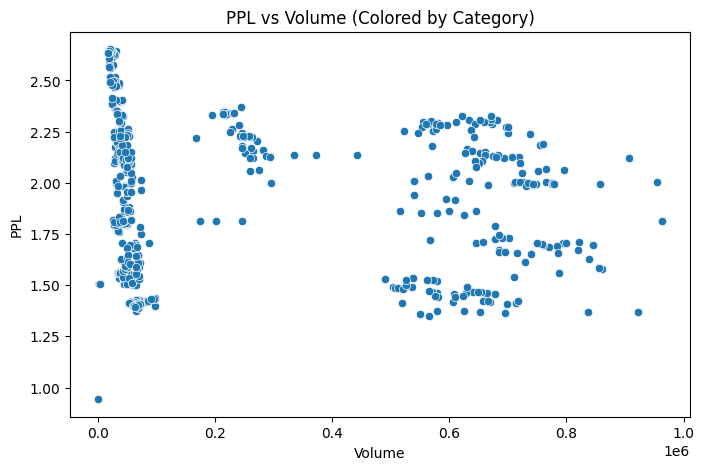

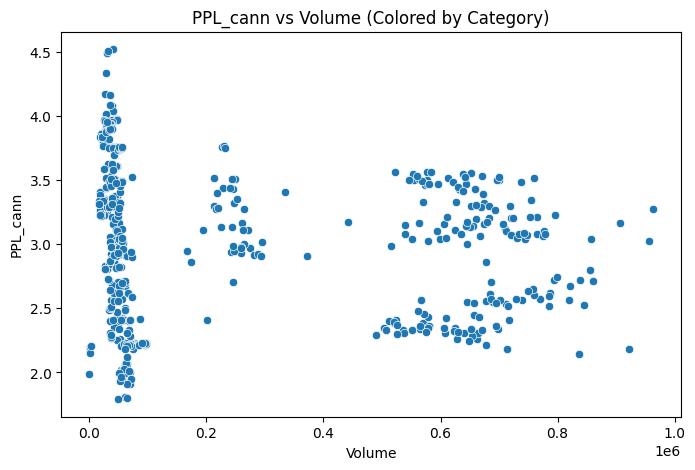

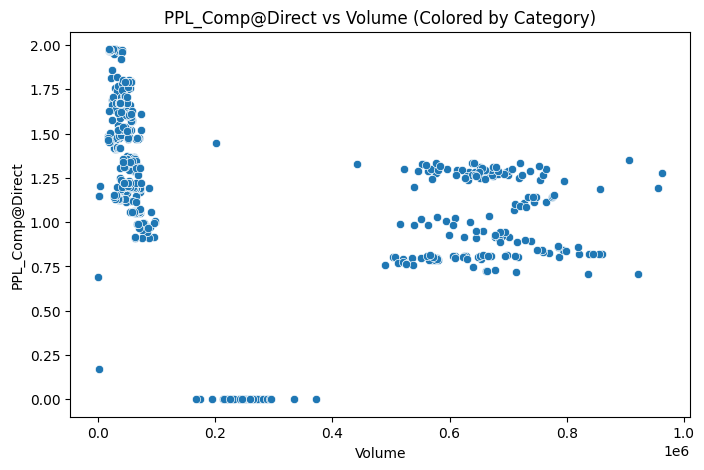

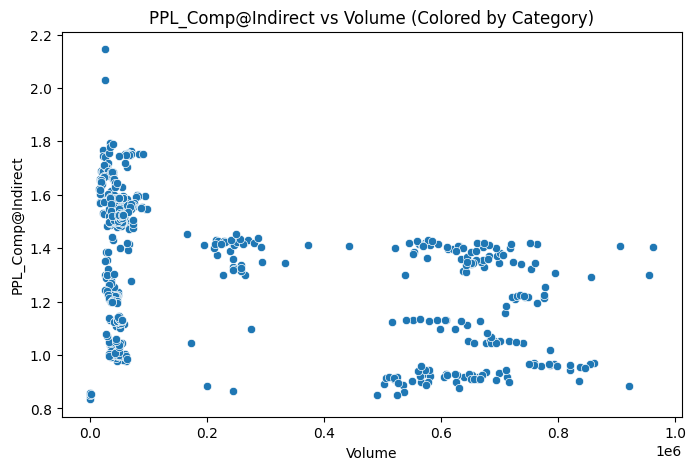

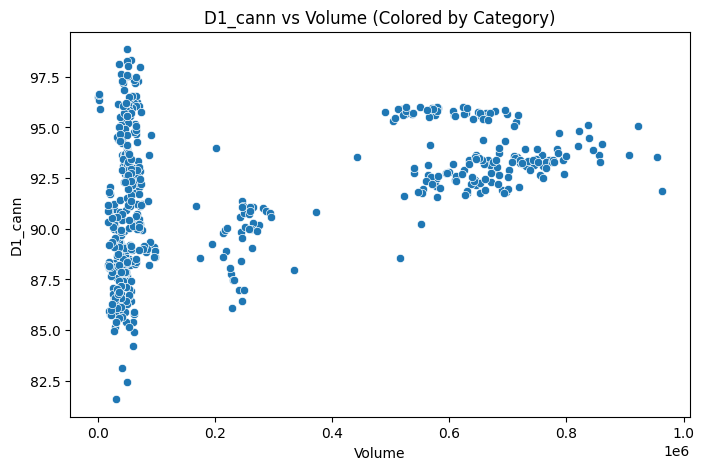

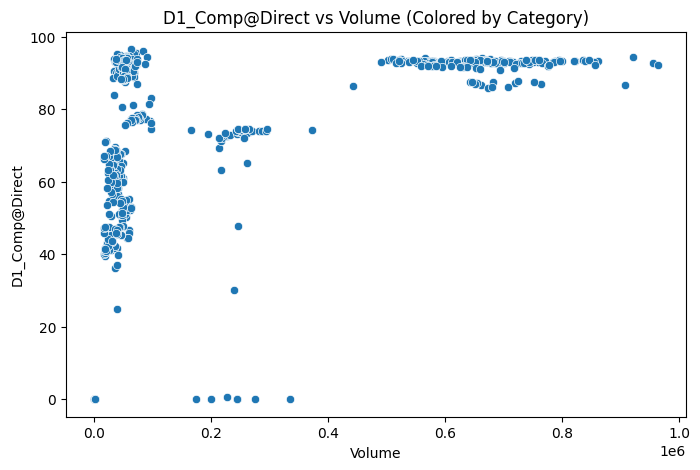

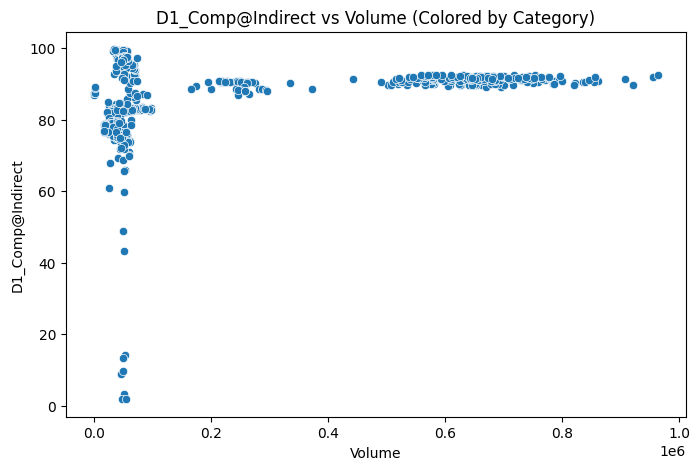

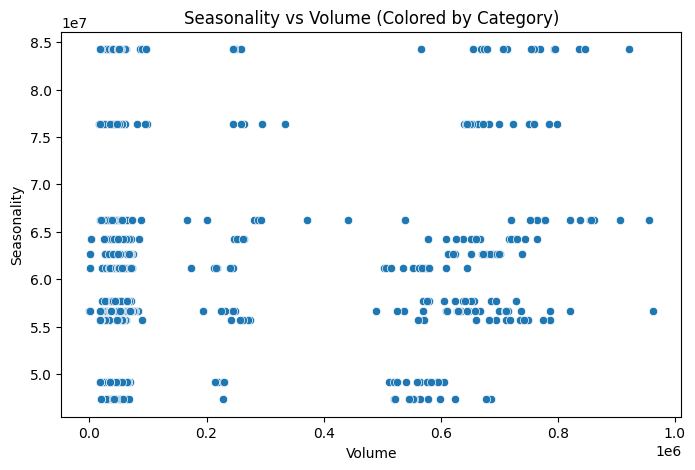

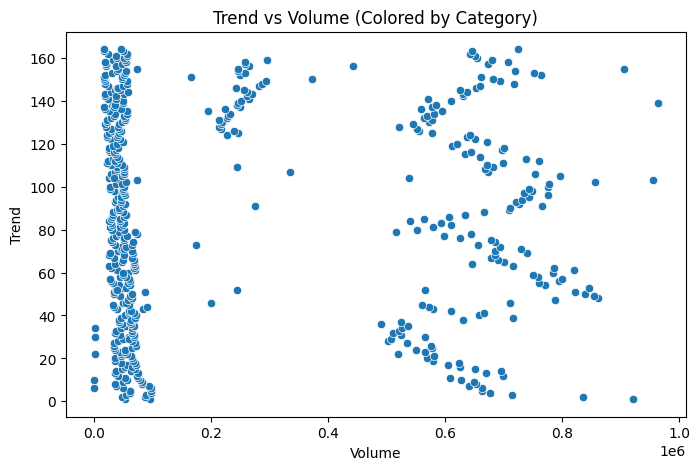

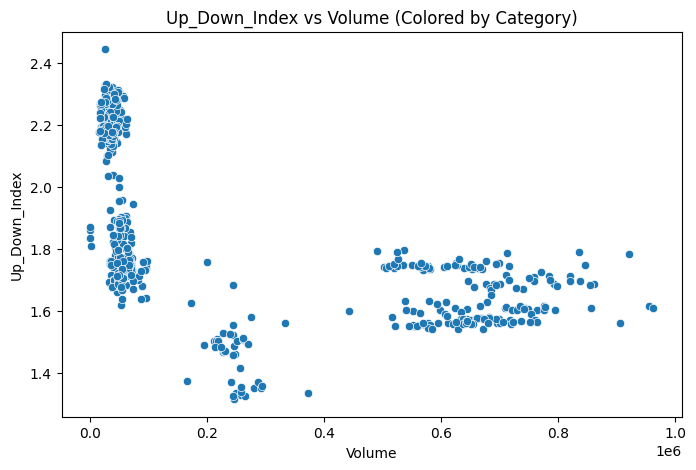

In [22]:

columns_to_plot=['PPL','PPL_cann','PPL_Comp@Direct','PPL_Comp@Indirect','D1_cann',
       'D1_Comp@Direct', 'D1_Comp@Indirect','Seasonality',
       'Trend','Up_Down_Index']

for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='Volume', y=col, data=df_col, palette='viridis')
    plt.title(f'{col} vs Volume (Colored by Category)')
    plt.xlabel('Volume')
    plt.ylabel(col)
    plt.show()



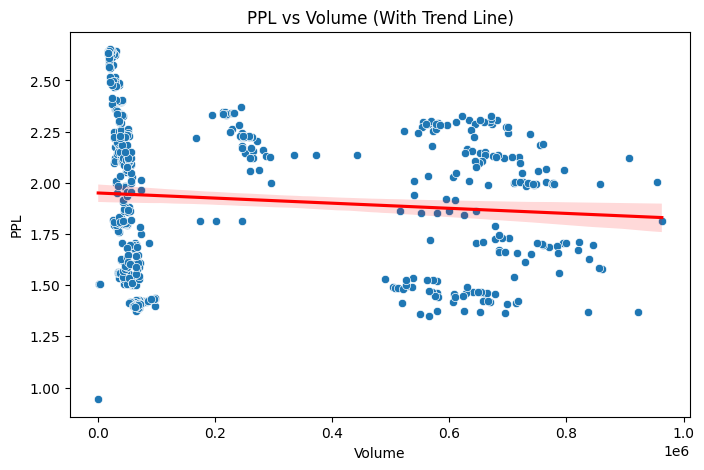

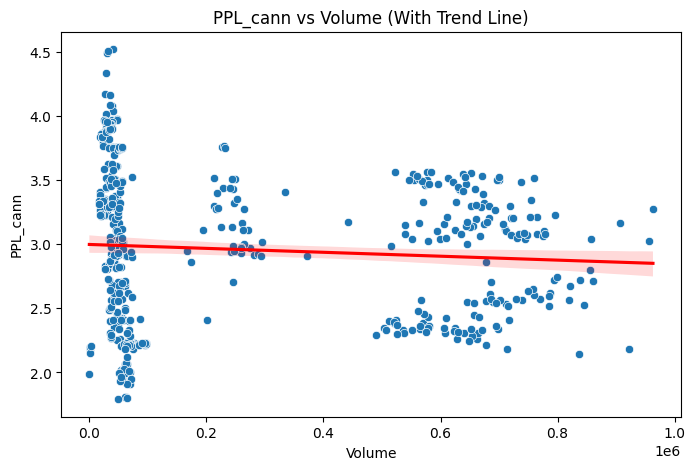

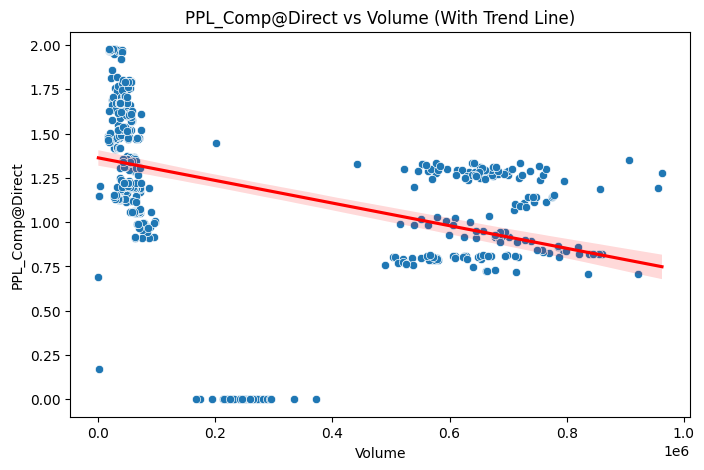

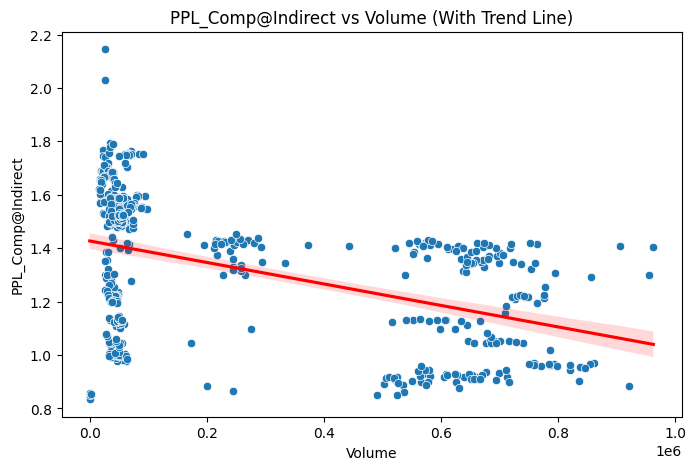

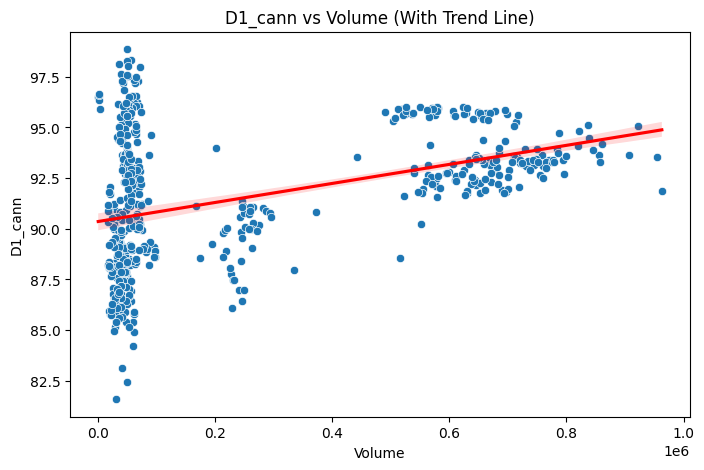

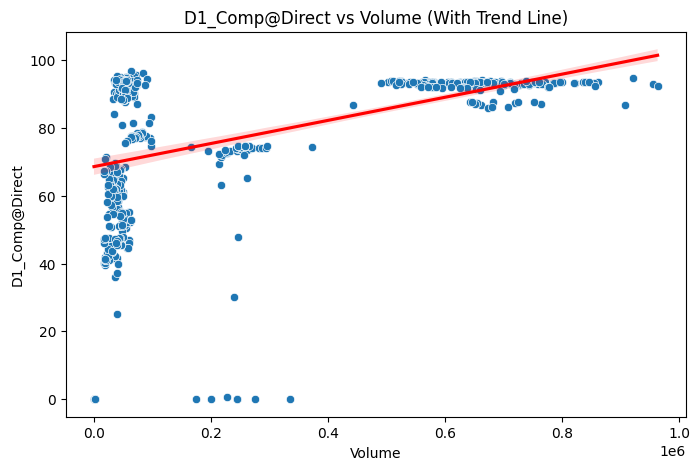

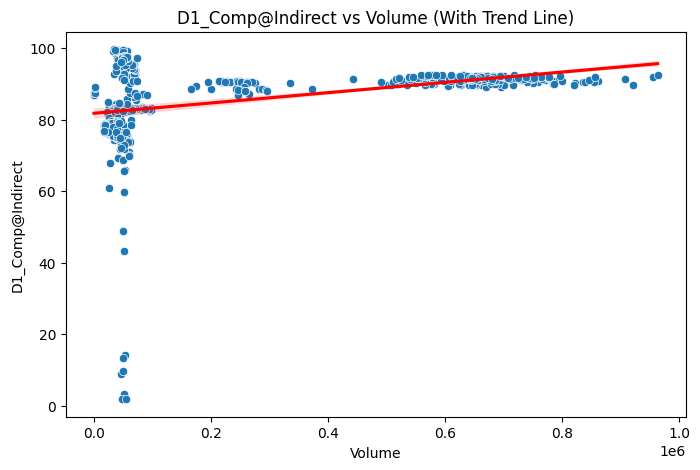

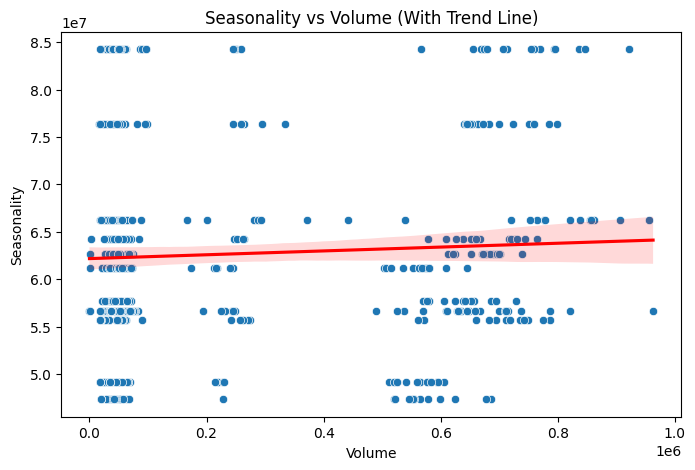

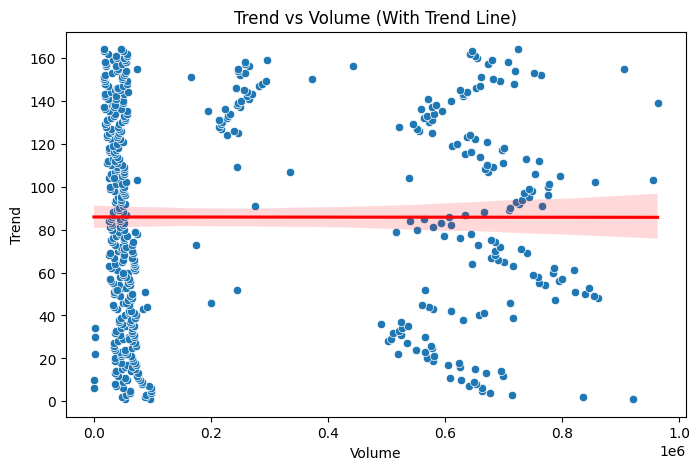

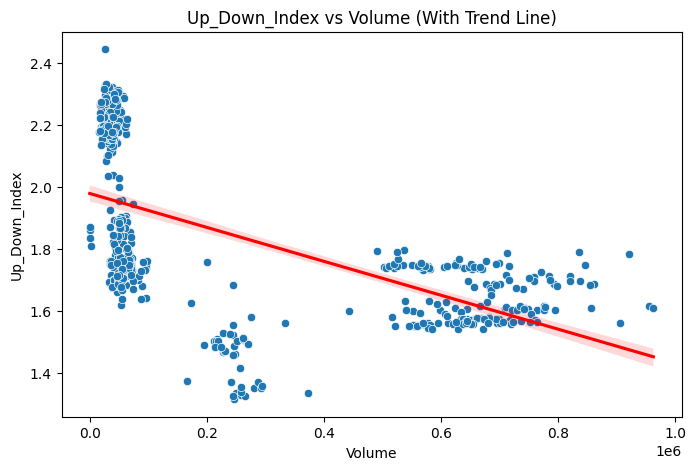

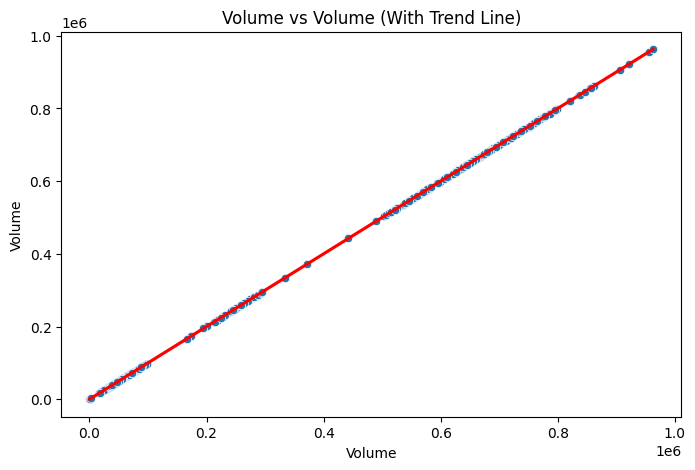

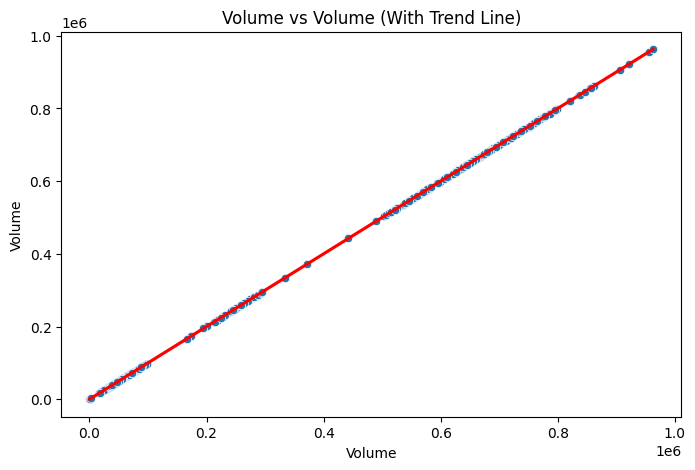

In [25]:
for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='Volume', y=col, data=df_col)
    sns.regplot(x='Volume', y=col, data=df_col, scatter=False, color='red')
    plt.title(f'{col} vs Volume (With Trend Line)')
    plt.xlabel('Volume')
    plt.ylabel(col)
    plt.show()


ValueError: Could not interpret value `Importance_Column` for `size`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [24]:
columns_to_plot.append('Volume')
columns_to_corr=columns_to_plot.append('Volume')

In [11]:
print(columns_to_corr)

['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'D1_cann', 'D1_Comp@Direct', 'D1_Comp@Indirect', 'Seasonality', 'Trend', 'Up_Down_Index', 'Volume']


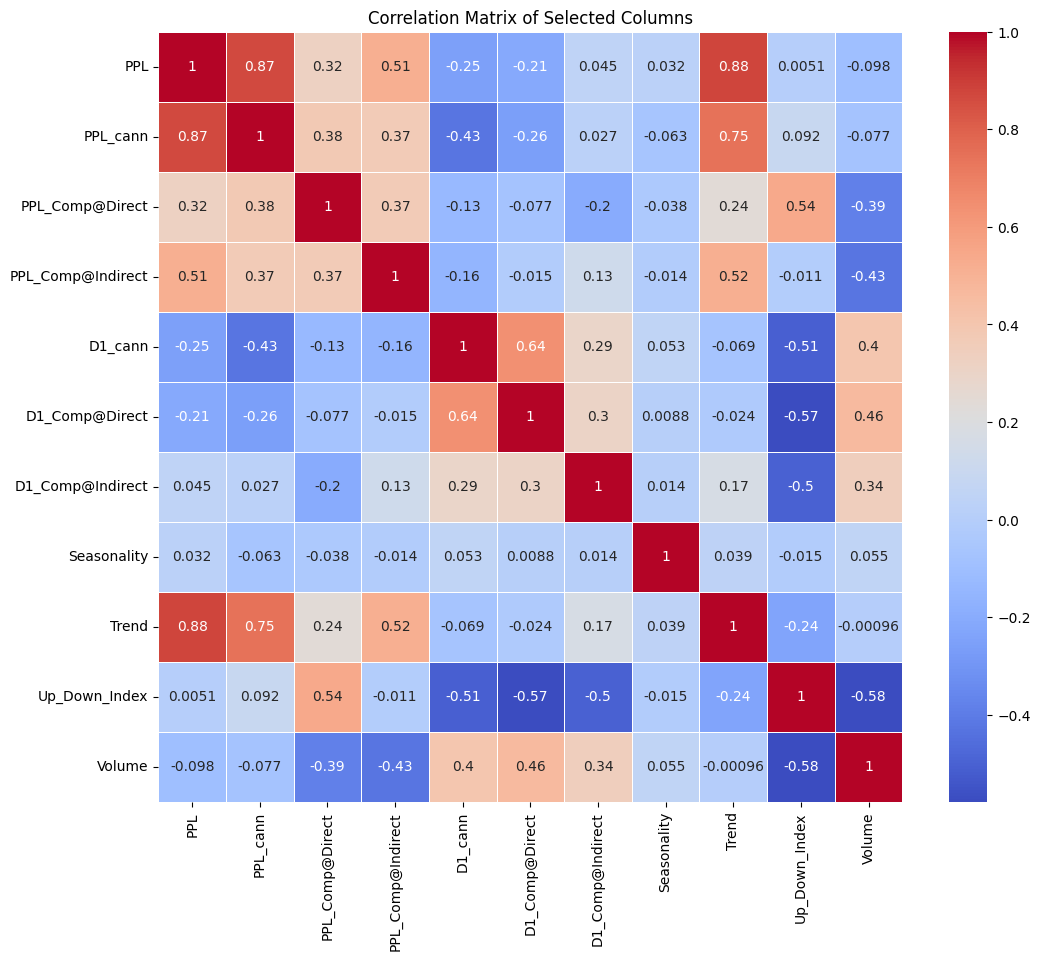

In [12]:
correlation_matrix = df_col[columns_to_corr].corr()
# Plotting the correlation matrix
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Selected Columns')
plt.show()